In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from compartments import (
    SEIR_patch_get_trajectory,
    CompartmentPatchArray,
    combine_mobility_agerates,
    get_patch_based_betas_from_unit_betas,
    calibirate_betas_seirv_patch,
    RunSimulationParams,
    run_packaged_simulation
)

ALPHA = 1/5.8
GAMMA = 1/5
WEIBULL_SCALE = 120
WEIBULL_SHAPE = 3.7

In [2]:
# I asked gemini to write this initial condition thingy. This 
# uses the initial condition from the units, number of people in the units
# and distributes them into patches
def build_initial_state(district_populations, age_fractions):
    """
    Constructs the (NUM_UNITS, NUM_AGES, 5) initial state tensor.
    
    district_populations: 1D array of total population per district
    age_fractions: 1D array of fractions that sum to 1.0 (e.g., [0.3, 0.4, 0.2, 0.1])
    """
    NUM_UNITS = len(district_populations)
    NUM_AGES = len(age_fractions)
    
    # 1. Verify fractions sum to 1.0 (with slight float tolerance)
    assert np.isclose(np.sum(age_fractions), 1.0), "Age fractions must sum to 1.0"
    
    # 2. Calculate the base population matrix (Shape: NUM_UNITS x NUM_AGES)
    # This multiplies every district pop by every age fraction
    base_populations = np.outer(district_populations, age_fractions)
    
    # 3. Initialize the State Tensor (Shape: NUM_UNITS, NUM_AGES, 5)
    # Compartments: [0:S, 1:E, 2:I, 3:R, 4:V]
    initial_state = np.zeros((NUM_UNITS, NUM_AGES, 5))
    
    # 4. Put EVERYONE into the Susceptible compartment (Index 0)
    initial_state[:, :, 0] = base_populations
    
    return initial_state

In [3]:
CASES_FILENAME = 'karnataka-data/IRDD_allka.csv'
CASESDATAFRAME = pd.read_csv(CASES_FILENAME)
KAGEOJSON = 'karnataka-data/karnataka_districts.geojson'
KAMAP = gpd.read_file(KAGEOJSON)

In [4]:
CASESDATAFRAME.head()

,Date,District,Infected,Recovered,Deceased
0,22-03-2020,Bagalakote,0,0,0
1,23-03-2020,Bagalakote,0,0,0
2,24-03-2020,Bagalakote,0,0,0
3,25-03-2020,Bagalakote,0,0,0
4,26-03-2020,Bagalakote,0,0,0


In [5]:
altframe = CASESDATAFRAME[CASESDATAFRAME['District']=='Karnataka']

In [6]:
# Remove karnataka and 'others' just for example
CASESDATAFRAME = CASESDATAFRAME[CASESDATAFRAME['District']!='Karnataka']
CASESDATAFRAME = CASESDATAFRAME[CASESDATAFRAME['District']!='Others']

In [7]:
CASESDATAFRAME['Date'] = pd.to_datetime(CASESDATAFRAME['Date'], dayfirst=True)
altframe['Date'] = pd.to_datetime(altframe['Date'], dayfirst=True)
CASESDATAFRAME

,Date,District,Infected,Recovered,Deceased
0,2020-03-22,Bagalakote,0,0,0
1,2020-03-23,Bagalakote,0,0,0
2,2020-03-24,Bagalakote,0,0,0
3,2020-03-25,Bagalakote,0,0,0
4,2020-03-26,Bagalakote,0,0,0
...,...,...,...,...,...
31285,2023-01-28,Yadgiri,41233,40710,522
31286,2023-01-29,Yadgiri,41233,40710,522
31287,2023-01-30,Yadgiri,41233,40711,522
31288,2023-01-31,Yadgiri,41233,40711,522


In [8]:
DISTRICTS_UNITS = CASESDATAFRAME['District'].unique()
DISTRICTS_UNITS = sorted(list(DISTRICTS_UNITS))
print(f'Number of Districts: {len(DISTRICTS_UNITS)}')
NUMDISTRICTS =len(DISTRICTS_UNITS)


Number of Districts: 30


In [9]:
KAMAP_DISTRICTS = list(KAMAP['name'].unique())
len(KAMAP_DISTRICTS)
KAMAP_DISTRICTS = sorted(KAMAP_DISTRICTS)
# for i, dist in enumerate(KAMAP_DISTRICTS):
#     print(dist, DISTRICTS_UNITS[i])

In [10]:
CASESDATAFRAME.head()

,Date,District,Infected,Recovered,Deceased
0,2020-03-22,Bagalakote,0,0,0
1,2020-03-23,Bagalakote,0,0,0
2,2020-03-24,Bagalakote,0,0,0
3,2020-03-25,Bagalakote,0,0,0
4,2020-03-26,Bagalakote,0,0,0


In [11]:
for dist in DISTRICTS_UNITS:
    print(dist)

Bagalakote
Ballari
Belagavi
Bengaluru Rural
Bengaluru Urban
Bidar
Chamarajanagara
Chikkaballapura
Chikkamagaluru
Chitradurga
Dakshina Kannada
Davanagere
Dharwad
Gadag
Hassan
Haveri
Kalaburagi
Kodagu
Kolar
Koppal
Mandya
Mysuru
Raichur
Ramanagara
Shivamogga
Tumakuru
Udupi
Uttara Kannada
Vijayapura
Yadgiri


## Calibirate the contact rates for the first wave before the vaccination

In [12]:
CASESDATAFRAME[CASESDATAFRAME['District']=='Others']

,Date,District,Infected,Recovered,Deceased


In [13]:
def get_district_cases(
        dataframe,
        district:str,
        init_date:str,
        end_date:str,
        compartment_name:str
        ):
    district_cases = CASESDATAFRAME[CASESDATAFRAME['District']==district]
    district_test_cases = district_cases[district_cases['Date']>=init_date]
    district_test_cases = district_test_cases[district_test_cases['Date']<end_date]
    district_cases_confirmed = np.array(district_test_cases[compartment_name])
    # print(district_test_cases.head(30))
    return district_cases_confirmed

In [14]:
test_date_init = '2020-10-11'
test_date_end = '2020-10-31'

validation_date_init = '2020-11-01'
validation_date_end = '2021-02-28'


case_per_spatial_unit_test = list()
case_per_spatial_unit_validation = list()
ka_cases = list()
total_cases_timeseries = list()
dist_list = list()
for district in DISTRICTS_UNITS:
    # print(district, type(district), district=='Bagalakote')
    if district!='Karnataka':
        test_cases_array = get_district_cases(
            CASESDATAFRAME,
            district = district,
            init_date=test_date_init,
            end_date= test_date_end,
            compartment_name='Infected'
            )
        
        test_cases_recovered = get_district_cases(
            CASESDATAFRAME,
            district = district,
            init_date=test_date_init,
            end_date= test_date_end,
            compartment_name='Recovered'
            )
        test_cases_deceased = get_district_cases(
            CASESDATAFRAME,
            district = district,
            init_date=test_date_init,
            end_date= test_date_end,
            compartment_name='Deceased'
            )
    
        
        validation_cases_array = get_district_cases(
            CASESDATAFRAME,
            district = district,
            init_date=validation_date_init,
            end_date= validation_date_end,
            compartment_name='Infected'
            )
        
        validation_cases_recovered = get_district_cases(
            CASESDATAFRAME,
            district = district,
            init_date=validation_date_init,
            end_date= validation_date_end,
            compartment_name='Recovered'
            )
        validation_cases_deceased = get_district_cases(
            CASESDATAFRAME,
            district = district,
            init_date=validation_date_init,
            end_date= validation_date_end,
            compartment_name='Deceased'
            )
    
        test_cases_array = test_cases_array- test_cases_deceased - test_cases_recovered
        validation_cases_array = validation_cases_array- validation_cases_deceased - validation_cases_recovered
        
        case_per_spatial_unit_test.append(test_cases_array)
        case_per_spatial_unit_validation.append(validation_cases_array)
    else:
        ka_cases.append(
            get_district_cases(
            CASESDATAFRAME,
            district = district,
            init_date=test_date_init,
            end_date= test_date_end,
            compartment_name='Infected'
            )
        )
    dist_list.append(district)

assert len(case_per_spatial_unit_test) == NUMDISTRICTS
test_total_cases = np.sum(np.array(case_per_spatial_unit_test), axis=0)
print(test_total_cases.shape)
steps_test = test_total_cases.shape[0]-1
assert len(case_per_spatial_unit_validation) == NUMDISTRICTS
validation_total_cases = np.sum(np.array(case_per_spatial_unit_validation), axis = 0)
print(validation_total_cases.shape)

steps_validation = validation_total_cases.shape[0]

print(validation_total_cases.shape,test_total_cases.shape)

(20,)
(119,)
(119,) (20,)


## LOADING THE AGE RATE MATRIX

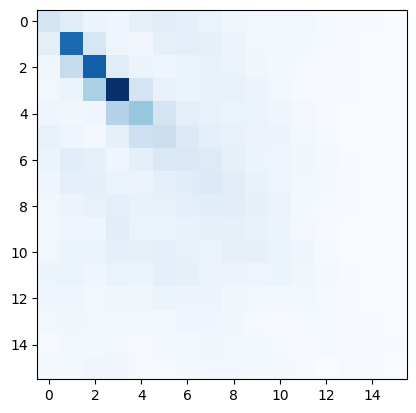

In [15]:
AGE_RATE_FILENAME = 'karnataka-data/ageinteractionmat.csv'
age_rate_matrix =np.loadtxt(AGE_RATE_FILENAME)
DELTA = 5
AGE_STRATIFICATION = [i*DELTA for i in range(age_rate_matrix.shape[0])]
plt.imshow(age_rate_matrix, cmap='Blues')
plt.show()

In [16]:
# get the fraction of people in age group
ka_age_group_distribution = pd.read_csv('karnataka-data/age_dist_projected_karnataka.csv')
total = ka_age_group_distribution['Population'].sum()
fraction_age_group = np.array(ka_age_group_distribution['Population'].iloc[:])
print(fraction_age_group.sum(), total)
fraction_age_group[-2] = fraction_age_group[-2] + fraction_age_group[-1]
fraction_age_group = fraction_age_group[:-1]/total
# print(fraction_age_group.sum(), total)
assert np.isclose(fraction_age_group.sum(),1)

66843 66843


## Defining a mobility matrix

In [17]:
MOBILITY_1 = np.eye(NUMDISTRICTS)

epsilon = 0.01
MOBILITY_2 = np.eye(len(DISTRICTS_UNITS))*(1-epsilon) + np.ones((NUMDISTRICTS, NUMDISTRICTS))*epsilon

In [18]:
# Combine to form a new network matrix
DISTRICTS_UNITS

['Bagalakote',
 'Ballari',
 'Belagavi',
 'Bengaluru Rural',
 'Bengaluru Urban',
 'Bidar',
 'Chamarajanagara',
 'Chikkaballapura',
 'Chikkamagaluru',
 'Chitradurga',
 'Dakshina Kannada',
 'Davanagere',
 'Dharwad',
 'Gadag',
 'Hassan',
 'Haveri',
 'Kalaburagi',
 'Kodagu',
 'Kolar',
 'Koppal',
 'Mandya',
 'Mysuru',
 'Raichur',
 'Ramanagara',
 'Shivamogga',
 'Tumakuru',
 'Udupi',
 'Uttara Kannada',
 'Vijayapura',
 'Yadgiri']

## Doing beta calibiration training from oct 11 to oct 31 2020

In [19]:
# Load initial fraction of recovered
name = 'karnataka-data/sero_ka_init.csv'
dataframe_sero = pd.read_csv(name)
dataframe_sero.head()

,Districts,% recovered,% infected,CIR
0,Bagalakote,4.1,9.7,30
1,Ballari,22.1,34.5,49
2,Belagavi,23.7,6.4,95
3,Bengaluru Rural,15.2,16.5,46
4,Bengaluru Urban,22.0,9.2,23


In [20]:
sero_infected_fraction = np.array(dataframe_sero['% infected']/100)
sero_recovered_fraction = np.array(dataframe_sero['% recovered']/100)
print(sero_infected_fraction, '\n', sero_recovered_fraction)

[0.097 0.345 0.064 0.165 0.092 0.007 0.066 0.059 0.21  0.16  0.135 0.292
 0.02  0.027 0.212 0.146 0.145 0.087 0.068 0.027 0.067 0.084 0.121 0.162
 0.137 0.252 0.228 0.087 0.139 0.186] 
 [0.041 0.221 0.237 0.152 0.22  0.18  0.158 0.064 0.12  0.102 0.145 0.164
 0.071 0.063 0.132 0.148 0.171 0.12  0.101 0.196 0.185 0.188 0.228 0.139
 0.077 0.068 0.162 0.081 0.239 0.154]


In [21]:
initial_projection = pd.read_excel('karnataka-data/finalPopulationData.xlsx')
initial_projection.head()

,district,data,2011_pop,Factor,Cowin Population
0,Kodagu,3.966888e+05,392248,1.011322,400000
1,Bagalakote,1.353783e+06,1194478,1.133368,1362000
2,Ballari,1.964513e+06,1555994,1.262545,2068000
3,Belagavi,3.523548e+06,3145147,1.120313,3566000
4,Bengaluru Rural,8.044783e+05,699465,1.150134,819000


In [22]:
projected_pop_dists = initial_projection['district'].unique()
projected_pop_dists = sorted(list(projected_pop_dists))
print(len(projected_pop_dists))
initial_projection= initial_projection.rename(columns = {'district': 'District'})
initial_projection= initial_projection.set_index('District').reindex(DISTRICTS_UNITS).reset_index()

30


In [23]:
initial_projection.head()

,District,data,2011_pop,Factor,Cowin Population
0,Bagalakote,1.353783e+06,1194478,1.133368,1362000
1,Ballari,1.964513e+06,1555994,1.262545,2068000
2,Belagavi,3.523548e+06,3145147,1.120313,3566000
3,Bengaluru Rural,8.044783e+05,699465,1.150134,819000
4,Bengaluru Urban,9.897156e+06,6988509,1.416204,10202000


In [44]:
fraction_age_group[:10]

array([0.0697156 , 0.07514624, 0.07584938, 0.0801131 , 0.08536421,
       0.08820669, 0.08807205, 0.08213276, 0.07260297, 0.06480858])

In [24]:
initial_projection.head()
initial_population_2020_district = np.array(initial_projection['Cowin Population'])
initial_condition_array = build_initial_state(district_populations=initial_population_2020_district, age_fractions= fraction_age_group)
# initial_condition_array[:, :, 1] = initial_condition_array[:, :, 0] * 0.127

initial_condition_array[1,:3]

array([[144171.86541597,      0.        ,      0.        ,
             0.        ,      0.        ],
       [155402.42059752,      0.        ,      0.        ,
             0.        ,      0.        ],
       [156856.5145191 ,      0.        ,      0.        ,
             0.        ,      0.        ]])

In [25]:
initial_condition_array[:, :, 2] = initial_condition_array[:, :, 0] * sero_infected_fraction[:, np.newaxis]
initial_condition_array[:, :, 3] = initial_condition_array[:, :, 0] * sero_recovered_fraction[:, np.newaxis]
initial_condition_array[:, :, 0] = initial_condition_array[:, :, 0] - np.sum(initial_condition_array[:, :, 1:], axis = 2)

In [26]:
initial_condition_array[1,:3]

array([[62570.58959053,     0.        , 49739.29356851, 31861.98225693,
            0.        ],
       [67444.65053932,     0.        , 53613.83510614, 34343.93495205,
            0.        ],
       [68075.72730129,     0.        , 54115.49750909, 34665.28970872,
            0.        ]])

In [27]:
initial_condition_array.shape

(30, 16, 5)

In [28]:
# initialised_cir = np.array([1/40]*NUMDISTRICTS)
initialised_cir = np.array(1/dataframe_sero['CIR'])
betas_units = np.array([0.0046308]*NUMDISTRICTS)
test_sim_params:RunSimulationParams = {
    'age_contact_matrix':age_rate_matrix,
    'unit_mobility_matrix':MOBILITY_1,
    'alpha':ALPHA,
    'gamma':GAMMA,
    'betas_units':None,
    'steps':steps_test,
    'initial_state_units_ages':initial_condition_array,
    'vaccination_daily_rate_patches':None,
    'vaccine_effect_time':14,
    'vaccine_efficacy':0.66,
    'waning_weibull_scale':WEIBULL_SCALE,
    'waning_weibull_shape':WEIBULL_SHAPE
}
print(steps_test)
betas_units, results, betasub = calibirate_betas_seirv_patch(
    simulation_params_init=test_sim_params,
    cir_units_init=initialised_cir,
    betas_units_init=betas_units,
    cases_reported_total= test_total_cases
)

19


In [29]:
results

           message: `xtol` termination condition is satisfied.
           success: True
            status: 2
               fun: 3.7185577854448866
                 x: [ 1.476e-05  4.076e-05 ...  2.646e-02  6.142e-06]
               nit: 269
              nfev: 14415
              njev: 465
              nhev: 0
          cg_niter: 3272
      cg_stop_cond: 2
              grad: [ 5.291e+04  6.923e+04 ...  3.831e+04  6.306e+04]
   lagrangian_grad: [ 1.152e-05  1.150e-04 ...  3.267e+00  2.379e-06]
            constr: [array([ 1.476e-05,  4.076e-05, ...,  2.646e-02,
                            6.142e-06], shape=(30,))]
               jac: [<Compressed Sparse Row sparse matrix of dtype 'float64'
                    	with 30 stored elements and shape (30, 30)>]
       constr_nfev: [0]
       constr_njev: [0]
       constr_nhev: [0]
                 v: [array([-5.291e+04, -6.923e+04, ..., -3.830e+04,
                           -6.306e+04], shape=(30,))]
            method: tr_interior_point

In [30]:
sim_params:RunSimulationParams = {
    'age_contact_matrix':age_rate_matrix,
    'unit_mobility_matrix':MOBILITY_1,
    'alpha':ALPHA,
    'gamma':GAMMA,
    'betas_units':betas_units,
    'steps':steps_test+steps_validation,
    'initial_state_units_ages':initial_condition_array,
    'vaccination_daily_rate_patches':None,
    'vaccine_effect_time':14,
    'vaccine_efficacy':0.66,
    'waning_weibull_scale':WEIBULL_SCALE,
    'waning_weibull_shape':WEIBULL_SHAPE
}
trajectory_patches = run_packaged_simulation(**sim_params)


Text(0.5, 1.0, 'Total Karnataka Cases from 2020-10-11 to 2021-02-28.\nWith the training window for contact rate calibiration ending\n at 2020-10-31')

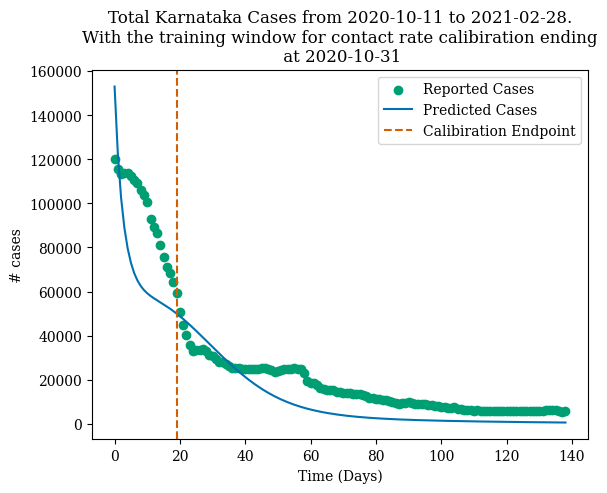

In [31]:
ka_total_predicted_test_plus_valudate = np.sum((np.sum(trajectory_patches[:,:,:,2], axis = 2)*1/40), axis= 1)
test_validate = np.concatenate((test_total_cases, validation_total_cases))
assert test_validate.shape == ka_total_predicted_test_plus_valudate.shape
plt.rcParams['font.family'] = 'serif'
reported_color = '#009E73'
predicted_color = '#0072B2'
endwindow = '#D55E00'
days = np.linspace(0, test_validate.shape[0]-1,test_validate.shape[0])
plt.scatter(days, test_validate, label = 'Reported Cases', color = reported_color)
plt.plot(ka_total_predicted_test_plus_valudate, label = 'Predicted Cases', color = predicted_color)
plt.axvline(x= steps_test, linestyle = 'dashed', color = endwindow, label = 'Calibiration Endpoint')
plt.legend()
plt.xlabel('Time (Days)')
plt.ylabel('# cases')
plt.title(f'Total Karnataka Cases from {test_date_init} to {validation_date_end}.\n'\
          f'With the training window for contact rate calibiration ending\n at {test_date_end}')
# plt.savefig('outputs/Total-ka-calibirated-oct-to-feb.png', dpi = 300)

## Checking unitwise cases

In [32]:
cases_total_units_data = np.hstack((np.array(case_per_spatial_unit_test), np.array(case_per_spatial_unit_validation)))
cases_total_units_data.shape

(30, 139)

In [33]:
trajectory_patches_infections = trajectory_patches[:,:,:,2]
trajectory_patches_infections_unit = trajectory_patches_infections.sum(axis = 2)
trajectory_patches_infections_unit.shape

(139, 30)

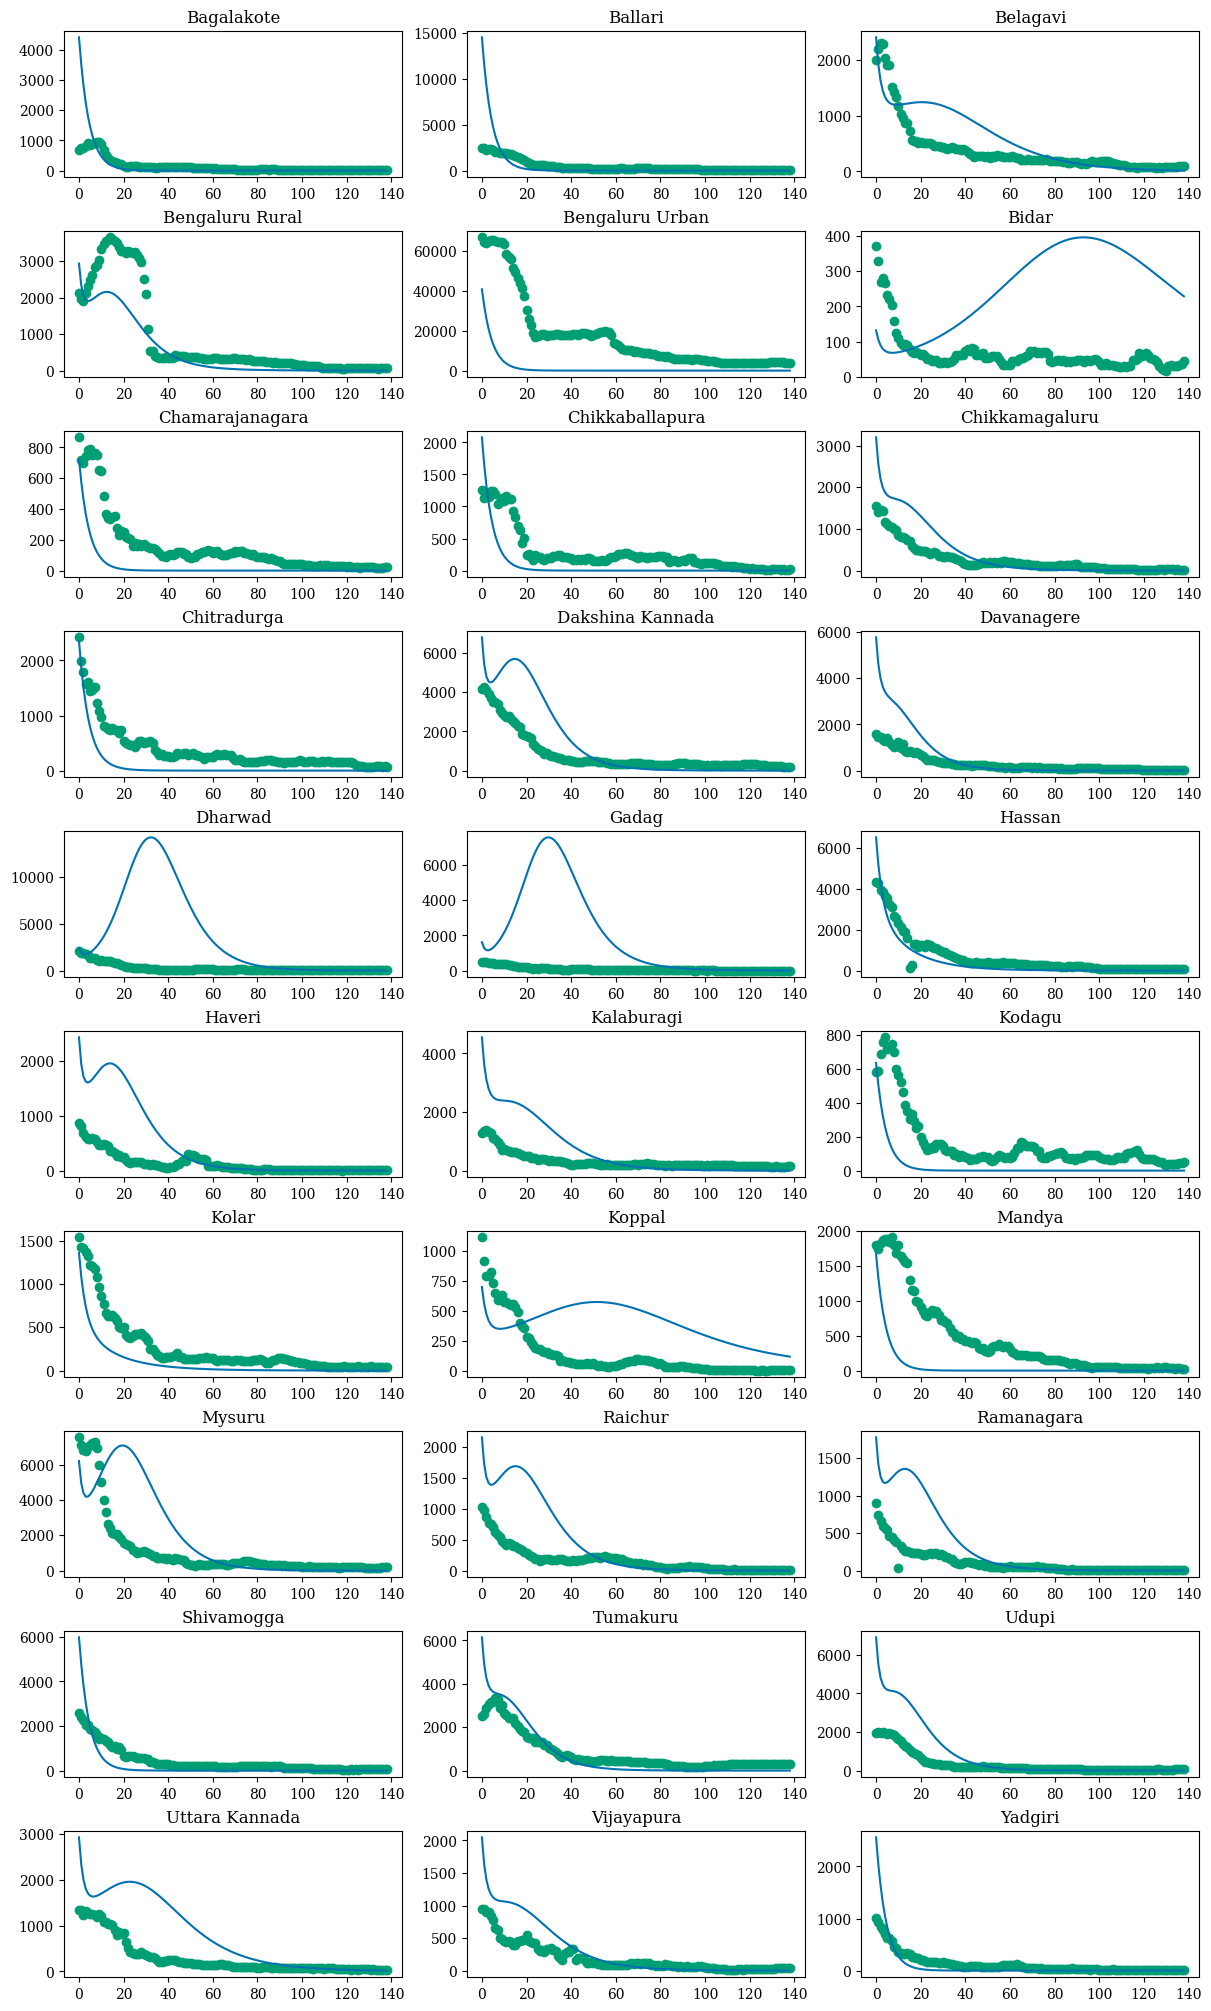

In [34]:
cols = 3
days = np.linspace(0, test_validate.shape[0]-1,test_validate.shape[0])
fig, axs = plt.subplots(nrows =10, ncols= cols, constrained_layout = True, figsize = (12, 20))
MSD = list()
for i, dist in enumerate(DISTRICTS_UNITS):
    axs[i//cols, i%cols].plot(trajectory_patches_infections_unit[:,i]*initialised_cir[i], color = predicted_color)
    axs[i//cols, i%cols].scatter(days, cases_total_units_data[i, :], color = reported_color)
    axs[i//cols, i%cols].set_title(dist)
    msd = np.sum((cases_total_units_data[i, :] - trajectory_patches_infections_unit[:,i])**2)
    MSD.append(msd)
# plt.savefig('outputs/unitwise-ka-calibirated-oct-to-feb.png', dpi = 300)


In [39]:
district = 'Bengaluru Rural'
index = DISTRICTS_UNITS.index(district)
trajectory_desired_unit = trajectory_patches_infections[:, index, :]
trajectory_desired_unit.shape

(139, 16)

In [45]:
fraction_age_group

array([0.0697156 , 0.07514624, 0.07584938, 0.0801131 , 0.08536421,
       0.08820669, 0.08807205, 0.08213276, 0.07260297, 0.06480858,
       0.05641578, 0.04700567, 0.03684754, 0.02818545, 0.02194695,
       0.02758703])

Text(0.5, 1.0, 'Infection across Age Groups in district of Bengaluru Rural')

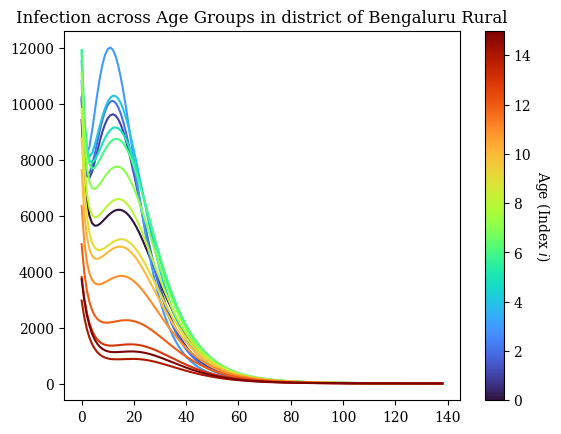

In [47]:
import matplotlib.cm as cm
# 1. Setup your colormap and normalisation
num_curves = trajectory_desired_unit.shape[1]
cmap = plt.get_cmap('turbo')
norm = plt.Normalize(vmin=0, vmax=num_curves - 1)

fig, ax = plt.subplots()

# 2. Plot lines with the gradient
for i in range(num_curves):
    ax.plot(trajectory_desired_unit[:, i], color=cmap(norm(i)))

# 3. Create the colorbar using a ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array for compatibility
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Age (Index $i$)', rotation=270, labelpad=15)
plt.title(f'Infection across Age Groups in district of {district}')